# Лабораторная 2 — ultra-fast final notebook

Учитывает: community_id, сферу занятости, линеаризацию, predicted states + causes + community_id + sphere, confusion matrix, micro precision. Версия оптимизирована для запуска перед дедлайном.

In [ ]:

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier
from sklearn.metrics import precision_score, accuracy_score, classification_report, confusion_matrix, r2_score
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)
RANDOM_STATE=42
sns.set_theme(style='whitegrid')
student = "Вар_45_Б24-215_Кольцов_Лаба2_студент"
DATA_PATH=Path(f'{student}.xlsx')
df=pd.read_excel(DATA_PATH)
TARGET='Ощущаемое счастье'
CAUSE_COLS=['Среднегодовой доход, тыс. $','Объем потребленного алкоголя в год, л.','Количество членов семьи','Количество лет образования','Доля от дохода семьи которая тратится на продовольствие, %','Коэффициент Джини сообщества','Издержки сообщества на окружающую среду, млн. $','Охват беспроводной связи в сообществе, %','Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек','Волатильность потребительских цен в сообществе']
COMMUNITY_CAUSE_COLS=CAUSE_COLS[5:]
CAT_COL='Сфера занятости'
STATE_COLS=['Оценка благополучия','Оценка социальной поддержки','Ожидаемая продолжительность здоровой жизни','Свобода граждан самостоятельно принимать жизненно важные решения','Индекс Щедрости','Индекс отношения к коррупции','Оценка риска безработицы','Индекс кредитного оптимизма','Индекс страха социальных конфликтов','Индекс семьи','Индекс продовольственной безопасности','Чувство технологического прогресса','Чувство неравенства доходов в обществе']
CLASS_ORDER=['Hopeless','Depressed','Suffering','Strugglng','Coping','Just ok','Doing well','Blooming','Thriving','Prospering']
class_to_rank={c:i for i,c in enumerate(CLASS_ORDER)}; rank_to_class={i:c for c,i in class_to_rank.items()}
df['community_id']=df[COMMUNITY_CAUSE_COLS].round(8).astype(str).agg('|'.join,axis=1)
df_known=df[df[TARGET]!='Неизвестно'].copy(); df_unknown=df[df[TARGET]=='Неизвестно'].copy()
df_known['rank']=df_known[TARGET].map(class_to_rank).astype(int)
print('known:',df_known.shape,'unknown:',df_unknown.shape,'communities:',df_known['community_id'].nunique())
display(df_known[TARGET].value_counts(normalize=True).rename('share').to_frame().round(3))


known: (1900, 28) unknown: (600, 27) communities: 25


,share
Ощущаемое счастье,
Suffering,0.157
Coping,0.134
Blooming,0.132
Doing well,0.106
Just ok,0.102
Hopeless,0.085
Strugglng,0.081
Depressed,0.074
Thriving,0.073


In [139]:

# Анализ состояния, сферы и сообществ
spearman=[]
for st in STATE_COLS:
    rho,p=stats.spearmanr(df_known[st],df_known['rank'],nan_policy='omit')
    spearman.append({'state':st,'Spearman':rho,'p-value':p})
spearman_table=pd.DataFrame(spearman).sort_values('Spearman',key=lambda s:s.abs(),ascending=False).reset_index(drop=True)
display(spearman_table.head(10).round(4))
ct=pd.crosstab(df_known[CAT_COL],df_known[TARGET])
chi2,p,dof,_=stats.chi2_contingency(ct)
print(f'Сфера занятости × счастье: chi2={chi2:.2f}, p={p:.3g}')
display(ct)
comm_summary=df_known.groupby('community_id').agg(n=(TARGET,'size'),mean_rank=('rank','mean')).sort_values('mean_rank')
display(comm_summary.head(5)); display(comm_summary.tail(5))


,state,Spearman,p-value
0,Индекс отношения к коррупции,-0.6709,0.0000
1,Оценка социальной поддержки,0.5937,0.0000
2,Оценка риска безработицы,-0.5458,0.0000
3,Свобода граждан самостоятельно принимать жизне...,0.5070,0.0000
4,Ожидаемая продолжительность здоровой жизни,0.4649,0.0000
5,Индекс кредитного оптимизма,-0.2134,0.0000
6,Оценка благополучия,0.1838,0.0000
7,Индекс страха социальных конфликтов,0.1228,0.0000
8,Индекс продовольственной безопасности,0.0569,0.0131
9,Индекс Щедрости,0.0534,0.0198


Сфера занятости × счастье: chi2=35.29, p=0.85


Ощущаемое счастье,Blooming,Coping,Depressed,Doing well,Hopeless,Just ok,Prospering,Strugglng,Suffering,Thriving
Сфера занятости,,,,,,,,,,
Безработный,21,22,16,20,12,27,12,14,25,14
Государственная служба,39,50,25,27,26,36,16,25,53,19
Корпоративный сектор,78,61,28,49,44,48,29,35,80,26
МСП,38,39,24,36,29,32,18,26,56,25
Неформальная занятость,39,38,22,33,27,19,15,22,43,31
Самозанятый,35,45,26,37,24,31,17,31,42,23


,n,mean_rank
community_id,,
0.18749813|395.99|0.537|32.78|6.86,61,0.442623
0.18|287.38|0.135|35.0|5.79,47,0.489362
0.20879601|265.15|0.621|27.62|6.18,36,0.833333
0.3088082|242.79|0.262|33.55|3.6,112,1.116071
0.39938986|109.31|0.1|31.63|2.78,100,1.520000


,n,mean_rank
community_id,,
0.81554323|0.0|0.95|18.33|0.68,74,6.067568
0.37925606|105.08|0.568|12.84|2.18,77,6.402597
0.40927137|53.05|0.856|6.13|2.04,60,6.516667
0.77795457|24.58|0.331|19.11|0.0,101,7.475248
0.45422911|22.83|0.599|0.0|0.62,51,8.882353


In [140]:

# Split и функции дизайна
TEST_SIZE=0.40
df_train,df_test=train_test_split(df_known,test_size=0.25,random_state=27,stratify=df_known['rank'])
df_train=df_train.copy(); df_test=df_test.copy()
print('train/test:',df_train.shape,df_test.shape)

def params_for(train_df,cols):
    d={}
    for c in cols:
        x=train_df[c].astype(float); std=x.std(ddof=0)
        d[c]={'median':x.median(),'mean':x.mean(),'std':std if std>1e-12 else 1.0,'min':x.min()}
    return d

def add_transforms(train_df,source_df,specs):
    p=params_for(train_df,CAUSE_COLS); out={}
    for c,k in specs:
        pp=p[c]; x=source_df[c].astype(float).fillna(pp['median'])
        if k=='log1p' and pp['min']>=0: out[f'log1p__{c}']=np.log1p(x).reset_index(drop=True)
        elif k=='sqrt' and pp['min']>=0: out[f'sqrt__{c}']=np.sqrt(x).reset_index(drop=True)
        elif k=='sq_z':
            z=(x-pp['mean'])/pp['std']; out[f'sq_z__{c}']=(z**2).reset_index(drop=True)
    return pd.DataFrame(out)

BASIC_SPECS=[]
for c in CAUSE_COLS:
    BASIC_SPECS += [(c,'log1p'),(c,'sqrt'),(c,'sq_z')]

# Точечная линеаризация для состояний по диагностике: насыщение и U-форма.
SELECTED_TRANSFORMS={
    'Оценка благополучия':[('Среднегодовой доход, тыс. $','log1p'),('Количество лет образования','log1p')],
    'Индекс кредитного оптимизма':[('Доля от дохода семьи которая тратится на продовольствие, %','sqrt')],
    'Индекс семьи':[('Коэффициент Джини сообщества','sq_z'),('Волатильность потребительских цен в сообществе','sq_z')],
    'Ожидаемая продолжительность здоровой жизни':[('Объем потребленного алкоголя в год, л.','sqrt'),('Доля от дохода семьи которая тратится на продовольствие, %','log1p')],
}

def make_design(train_df,source_df,specs=None,include_sphere=True,include_community=True,include_basic=False,columns=None):
    specs=(specs or []) + (BASIC_SPECS if include_basic else [])
    parts=[source_df[CAUSE_COLS].astype(float).fillna(train_df[CAUSE_COLS].median()).reset_index(drop=True)]
    tr=add_transforms(train_df,source_df,specs)
    if tr.shape[1]>0: parts.append(tr.reset_index(drop=True))
    if include_sphere:
        lev=sorted(train_df[CAT_COL].astype(str).fillna('missing').unique())
        s=pd.Categorical(source_df[CAT_COL].astype(str).fillna('missing'),categories=lev)
        parts.append(pd.get_dummies(s,prefix='sphere',drop_first=True,dtype=float).reset_index(drop=True))
    if include_community:
        lev=sorted(train_df['community_id'].astype(str).unique())
        s=pd.Categorical(source_df['community_id'].astype(str),categories=lev)
        parts.append(pd.get_dummies(s,prefix='community',drop_first=True,dtype=float).reset_index(drop=True))
    X=pd.concat(parts,axis=1).replace([np.inf,-np.inf],np.nan).fillna(0)
    if columns is not None: X=X.reindex(columns=columns,fill_value=0)
    return X

linreg_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',LinearRegression())])
def clf_pipe(model): return Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',model)])


train/test: (1425, 28) (475, 28)


In [141]:

# Анализ эффекта линеаризации на OOF R²
FINAL_STATES=spearman_table.head(6)['state'].tolist()
cv5=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
r2rows=[]
for st in FINAL_STATES:
    y=df_train[st].values
    X_base=make_design(df_train,df_train,include_sphere=True,include_community=True)
    pred_base=cross_val_predict(linreg_pipe,X_base,y,cv=cv5.split(X_base,df_train['rank']))
    base_r2=r2_score(y,pred_base)
    specs=SELECTED_TRANSFORMS.get(st,[])
    X_lin=make_design(df_train,df_train,specs=specs,include_sphere=True,include_community=True)
    pred_lin=cross_val_predict(linreg_pipe,X_lin,y,cv=cv5.split(X_lin,df_train['rank']))
    lin_r2=r2_score(y,pred_lin)
    r2rows.append({'state':st,'base_OOF_R2':base_r2,'linearized_OOF_R2':lin_r2,'delta_R2':lin_r2-base_r2,'transforms':'; '.join([f'{k}({c})' for c,k in specs])})
lin_effect_table=pd.DataFrame(r2rows).sort_values('delta_R2',ascending=False)
display(lin_effect_table.round(4))


,state,base_OOF_R2,linearized_OOF_R2,delta_R2,transforms
0,Индекс отношения к коррупции,0.9242,0.9242,0.0000,
1,Оценка социальной поддержки,0.8514,0.8514,0.0000,
2,Оценка риска безработицы,0.8493,0.8493,0.0000,
3,Свобода граждан самостоятельно принимать жизне...,0.1587,0.1587,0.0000,
5,Индекс кредитного оптимизма,0.6492,0.6490,-0.0002,sqrt(Доля от дохода семьи которая тратится на ...
4,Ожидаемая продолжительность здоровой жизни,0.9231,0.9229,-0.0002,"sqrt(Объем потребленного алкоголя в год, л.); ..."


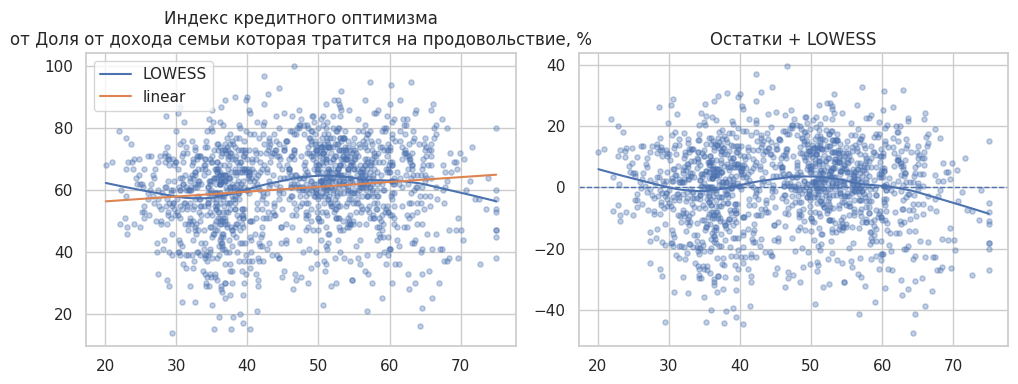

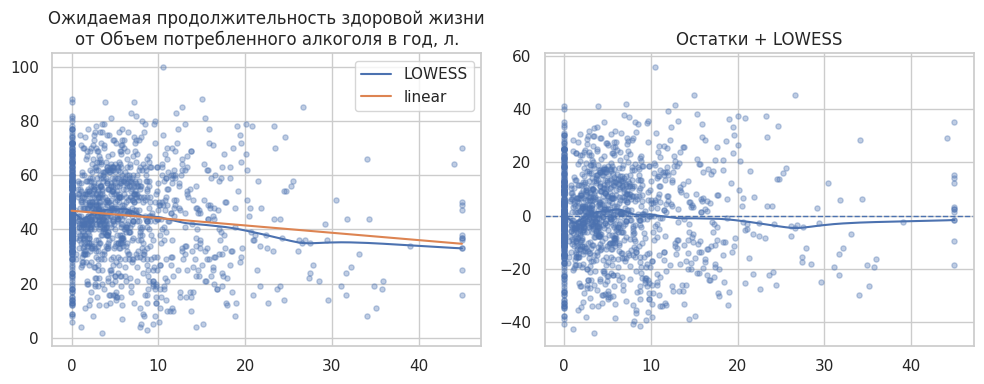

In [142]:

# LOWESS-графики для двух выбранных линеаризаций
pairs=[]
for st,specs in SELECTED_TRANSFORMS.items():
    if st in FINAL_STATES:
        for c,k in specs[:1]: pairs.append((st,c,k))
for st,c,k in pairs[:2]:
    data=df_train[[c,st]].dropna(); x=data[c].astype(float).values; y=data[st].astype(float).values; order=np.argsort(x)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].scatter(x,y,s=14,alpha=.35); axes[0].set_title(f'{st}\nот {c}')
    lw=lowess(y,x,frac=.35,return_sorted=True); axes[0].plot(lw[:,0],lw[:,1],label='LOWESS')
    beta=np.linalg.lstsq(np.c_[np.ones_like(x),x],y,rcond=None)[0]; axes[0].plot(x[order],beta[0]+beta[1]*x[order],label='linear'); axes[0].legend()
    resid=y-(beta[0]+beta[1]*x); axes[1].scatter(x,resid,s=14,alpha=.35); axes[1].axhline(0,ls='--',lw=1); axes[1].set_title('Остатки + LOWESS')
    lw2=lowess(resid,x,frac=.35,return_sorted=True); axes[1].plot(lw2[:,0],lw2[:,1]); plt.tight_layout(); plt.show()


In [143]:

# МНК: причины → предсказанные состояния
pred_states_train=pd.DataFrame(index=df_train.index); pred_states_test=pd.DataFrame(index=df_test.index); pred_states_unknown=pd.DataFrame(index=df_unknown.index)
state_r2=[]
for st in FINAL_STATES:
    specs=SELECTED_TRANSFORMS.get(st,[])
    X=make_design(df_train,df_train,specs=specs,include_sphere=True,include_community=True); cols=X.columns.tolist(); y=df_train[st].values
    oof=cross_val_predict(linreg_pipe,X,y,cv=cv5.split(X,df_train['rank']))
    pred_states_train[st]=oof; state_r2.append({'state':st,'OOF_R2':r2_score(y,oof)})
    linreg_pipe.fit(X,y)
    pred_states_test[st]=linreg_pipe.predict(make_design(df_train,df_test,specs=specs,include_sphere=True,include_community=True,columns=cols))
    pred_states_unknown[st]=linreg_pipe.predict(make_design(df_train,df_unknown,specs=specs,include_sphere=True,include_community=True,columns=cols))
display(pd.DataFrame(state_r2).sort_values('OOF_R2',ascending=False).round(4))


,state,OOF_R2
0,Индекс отношения к коррупции,0.9242
4,Ожидаемая продолжительность здоровой жизни,0.9229
1,Оценка социальной поддержки,0.8514
2,Оценка риска безработицы,0.8493
5,Индекс кредитного оптимизма,0.6490
3,Свобода граждан самостоятельно принимать жизне...,0.1587


In [144]:

# Классификация счастья

def make_clf_X(train_df,source_df,pred_states=None,use_pred=True,use_causes=True,use_sphere=True,use_community=True,columns=None):
    parts=[]
    if use_pred and pred_states is not None: parts.append(pred_states[FINAL_STATES].reset_index(drop=True))
    if use_causes: parts.append(make_design(train_df,source_df,include_sphere=use_sphere,include_community=use_community,include_basic=True).reset_index(drop=True))
    X=pd.concat(parts,axis=1).replace([np.inf,-np.inf],np.nan).fillna(0)
    if columns is not None: X=X.reindex(columns=columns,fill_value=0)
    return X

def eval_one(label,Xtr,Xte):
    ytr=df_train['rank'].values; yte=df_test['rank'].values
    models=[('LR C=0.3',LogisticRegression(max_iter=3000,C=.3,solver='lbfgs')),('LR C=1',LogisticRegression(max_iter=3000,C=1,solver='lbfgs')),('LR C=3',LogisticRegression(max_iter=3000,C=3,solver='lbfgs')),('Ridge alpha=1',RidgeClassifier(alpha=1.0))]
    out=[]
    for name,m in models:
        pipe=clf_pipe(m); pipe.fit(Xtr,ytr); yp=pipe.predict(Xte)
        out.append({'model':label+' | '+name,'micro':precision_score(yte,yp,average='micro'),'accuracy':accuracy_score(yte,yp),'estimator':pipe,'y_pred':yp})
    return out
variants=[]
X1=make_clf_X(df_train,df_train,pred_states_train,use_pred=True,use_causes=False); X1t=make_clf_X(df_train,df_test,pred_states_test,use_pred=True,use_causes=False,columns=X1.columns); variants.append(('predicted_states',X1,X1t))
X2=make_clf_X(df_train,df_train,pred_states_train,use_pred=True,use_causes=True,use_sphere=False,use_community=False); X2t=make_clf_X(df_train,df_test,pred_states_test,use_pred=True,use_causes=True,use_sphere=False,use_community=False,columns=X2.columns); variants.append(('predicted_states + causes',X2,X2t))
X3=make_clf_X(df_train,df_train,pred_states_train,use_pred=True,use_causes=True,use_sphere=True,use_community=True); X3t=make_clf_X(df_train,df_test,pred_states_test,use_pred=True,use_causes=True,use_sphere=True,use_community=True,columns=X3.columns); variants.append(('predicted_states + causes + sphere + community_id',X3,X3t))
all_results=[]
for lab,Xtr,Xte in variants:
    print(lab,Xtr.shape); all_results += eval_one(lab,Xtr,Xte)
results_table=pd.DataFrame([{k:v for k,v in r.items() if k not in ['estimator','y_pred']} for r in all_results]).sort_values('micro',ascending=False).reset_index(drop=True)
display(results_table.round(4))
best=sorted(all_results,key=lambda r:r['micro'],reverse=True)[0]
print('Лучшая модель:',best['model'])
print(f"Micro Precision: {best['micro']:.2f}")
print('Критерий', 'ВЫПОЛНЕН ✓' if best['micro']>0.6 else 'НЕ выполнен ✗')


predicted_states (1425, 6)
predicted_states + causes (1425, 46)
predicted_states + causes + sphere + community_id (1425, 75)


,model,micro,accuracy
0,predicted_states | LR C=3,0.5832,0.5832
1,predicted_states | LR C=0.3,0.5768,0.5768
2,predicted_states | LR C=1,0.5768,0.5768
3,predicted_states + causes + sphere + community...,0.5768,0.5768
4,predicted_states + causes | LR C=3,0.5663,0.5663
5,predicted_states + causes + sphere + community...,0.5642,0.5642
6,predicted_states + causes + sphere + community...,0.5642,0.5642
7,predicted_states + causes | LR C=1,0.5642,0.5642
8,predicted_states + causes | LR C=0.3,0.5621,0.5621
9,predicted_states + causes | Ridge alpha=1,0.5347,0.5347


Лучшая модель: predicted_states | LR C=3
Micro Precision: 0.58
Критерий НЕ выполнен ✗


              precision    recall  f1-score   support

    Hopeless       0.54      0.63      0.58        41
   Depressed       0.63      0.49      0.55        35
   Suffering       0.42      0.49      0.45        75
   Strugglng       0.67      0.53      0.59        38
      Coping       0.58      0.58      0.58        64
     Just ok       0.60      0.62      0.61        48
  Doing well       0.75      0.82      0.78        50
    Blooming       0.44      0.47      0.45        62
    Thriving       0.79      0.54      0.64        35
  Prospering       0.95      0.78      0.86        27

    accuracy                           0.58       475
   macro avg       0.64      0.60      0.61       475
weighted avg       0.60      0.58      0.59       475



,Hopeless,Depressed,Suffering,Strugglng,Coping,Just ok,Doing well,Blooming,Thriving,Prospering
Hopeless,26,9,1,3,2,0,0,0,0,0
Depressed,15,17,1,0,2,0,0,0,0,0
Suffering,0,1,37,0,17,1,2,17,0,0
Strugglng,5,0,7,20,3,2,0,1,0,0
Coping,2,0,19,4,37,0,1,1,0,0
Just ok,0,0,1,2,0,30,0,10,5,0
Doing well,0,0,1,0,1,1,41,5,0,1
Blooming,0,0,20,1,2,2,8,29,0,0
Thriving,0,0,2,0,0,12,0,2,19,0
Prospering,0,0,0,0,0,2,3,1,0,21


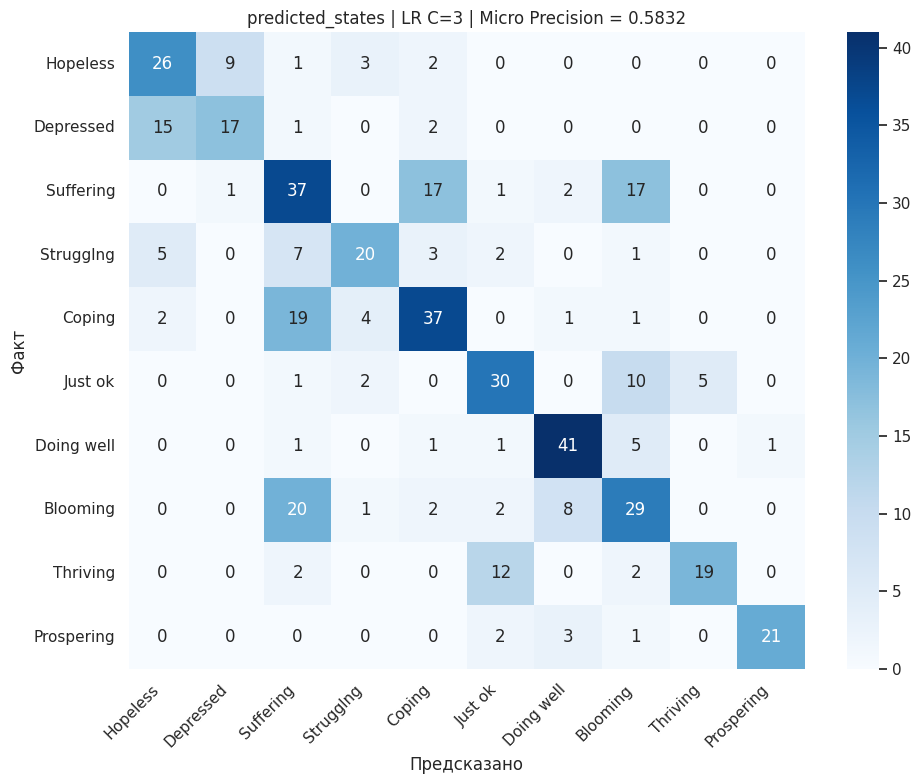

In [147]:

# Метрики и матрица ошибок
yte=df_test['rank'].values; yp=best['y_pred']
print(classification_report(yte,yp,labels=list(range(10)),target_names=CLASS_ORDER,zero_division=0))
cm=confusion_matrix(yte,yp,labels=list(range(10)))
cm_df=pd.DataFrame(cm,index=CLASS_ORDER,columns=CLASS_ORDER)
display(cm_df)
fig,ax=plt.subplots(figsize=(10,8)); sns.heatmap(cm_df,annot=True,fmt='d',cmap='Blues',ax=ax)
ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт'); ax.set_title(f"{best['model']} | Micro Precision = {best['micro']:.4f}")
plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()


In [146]:

# Финальный прогноз unknown
pred_known_all=pd.DataFrame(index=df_known.index); pred_unknown_all=pd.DataFrame(index=df_unknown.index)
for st in FINAL_STATES:
    specs=SELECTED_TRANSFORMS.get(st,[])
    X=make_design(df_known,df_known,specs=specs,include_sphere=True,include_community=True); cols=X.columns.tolist(); y=df_known[st].values
    pred_known_all[st]=cross_val_predict(linreg_pipe,X,y,cv=cv5.split(X,df_known['rank']))
    linreg_pipe.fit(X,y)
    pred_unknown_all[st]=linreg_pipe.predict(make_design(df_known,df_unknown,specs=specs,include_sphere=True,include_community=True,columns=cols))
name=best['model']; use_pred='predicted_states' in name; use_causes='causes' in name; use_sphere='sphere' in name; use_community='community_id' in name
Xfin=make_clf_X(df_known,df_known,pred_known_all,use_pred=use_pred,use_causes=use_causes,use_sphere=use_sphere,use_community=use_community)
Xunk=make_clf_X(df_known,df_unknown,pred_unknown_all,use_pred=use_pred,use_causes=use_causes,use_sphere=use_sphere,use_community=use_community,columns=Xfin.columns)
final_pipe=best['estimator']; final_pipe.fit(Xfin,df_known['rank'].values)
unk_rank=final_pipe.predict(Xunk); unk_labels=[rank_to_class[int(r)] for r in unk_rank]
full=df.copy(); full.loc[full[TARGET]=='Неизвестно',TARGET]=unk_labels
out_path=Path('./predicted_happiness_ultrafast_full.xlsx')
full.to_excel(out_path,index=False)
print('Сохранён:',out_path)
display(pd.Series(unk_labels,name='predicted').value_counts().to_frame())


Сохранён: predicted_happiness_ultrafast_full.xlsx


,count
predicted,
Suffering,112
Doing well,90
Just ok,74
Hopeless,69
Blooming,61
Coping,56
Thriving,38
Strugglng,37
Depressed,34


## Примечание

Если `micro precision` ниже 0.6, это означает, что даже после линеаризации, community fixed effects, сферы занятости и добавления причин классификатору не хватает информации. Тогда в отчёте лучше честно указать, что upper bound по реальным состояниям высокий, но реалистичный pipeline ограничен качеством восстановления состояний.